In [ ]:
!curl -L -o ./data/csgo-matchmaking-damage.zip https://www.kaggle.com/api/v1/datasets/download/skihikingkevin/csgo-matchmaking-damage
!unzip ./data/csgo-matchmaking-damage.zip

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

## Reading in the data
### It is done this way because the master dmg csv cell takes around a minute to run and would hate to have to re-run that 10+ times a sessions 

In [4]:
dmg_pt1 = pd.read_csv('../data/esea_master_dmg_demos.part1.csv')
dmg_pt2 = pd.read_csv('../data/esea_master_dmg_demos.part2.csv')
dmg = pd.concat([dmg_pt1, dmg_pt2])

In [6]:
grenades_pt1 = pd.read_csv('../data/esea_master_grenades_demos.part1.csv')
grenades_pt2 = pd.read_csv('../data/esea_master_grenades_demos.part2.csv')
grenades = pd.concat([grenades_pt1, grenades_pt2])

In [7]:
frags_pt1 = pd.read_csv('../data/esea_master_kills_demos.part1.csv')
frags_pt2 = pd.read_csv('../data/esea_master_kills_demos.part2.csv')
frags = pd.concat([frags_pt1, frags_pt2])

# Building the player stats PER MATCH (this needs to be aggregated)

In [8]:
def build_player_match_stats(dmg_df, nade_df, match_col='file'):
    # -----------------------
    # TOTAL DAMAGE (all damage events from dmg_df)
    # -----------------------
    total = (
        dmg_df.groupby([match_col, 'att_id'])['hp_dmg']
        .sum()
        .reset_index()
        .rename(columns={'att_id': 'player', 'hp_dmg': 'total_raw_damage'})
    )

    # -----------------------
    # NADE DAMAGE (attacker)
    # -----------------------
    nade = (
        nade_df.groupby([match_col, 'att_id'])['hp_dmg']
        .sum()
        .reset_index()
        .rename(columns={'att_id': 'player', 'hp_dmg': 'nade_damage'})
    )

    # -----------------------
    # GUN DAMAGE = TOTAL RAW DAMAGE - NADE DAMAGE
    # -----------------------
    gun = total.merge(nade, on=[match_col, 'player'], how='left')
    gun['nade_damage'] = gun['nade_damage'].fillna(0)
    gun['gun_damage'] = gun['total_raw_damage'] - gun['nade_damage']

    # -----------------------
    # DAMAGE TAKEN (victim)
    # -----------------------
    taken = (
        dmg_df.groupby([match_col, 'vic_id'])['hp_dmg']
        .sum()
        .reset_index()
        .rename(columns={'vic_id': 'player', 'hp_dmg': 'damage_taken'})
    )

    # -----------------------
    # ROUNDS PLAYED
    # -----------------------
    rounds = (
        pd.concat([
            dmg_df[[match_col, 'round', 'att_id']].rename(columns={'att_id': 'player'}),
            dmg_df[[match_col, 'round', 'vic_id']].rename(columns={'vic_id': 'player'})
        ])
        .drop_duplicates()
        .groupby([match_col, 'player'])['round']
        .nunique()
        .reset_index(name='rounds_played')
    )

    # -----------------------
    # MERGE EVERYTHING
    # -----------------------
    df = gun[[match_col, 'player', 'gun_damage', 'nade_damage']].merge(
        taken, on=[match_col, 'player'], how='outer'
    )
    df = df.merge(rounds, on=[match_col, 'player'], how='outer')

    # -----------------------
    # CLEAN
    # -----------------------
    df[['gun_damage', 'nade_damage', 'damage_taken', 'rounds_played']] = (
        df[['gun_damage', 'nade_damage', 'damage_taken', 'rounds_played']]
        .fillna(0)
    )

    # Optional: remove non-player ID 0
    df = df[df['player'] != 0]

    # -----------------------
    # DERIVED FEATURES
    # -----------------------
    df['total_damage'] = df['gun_damage'] + df['nade_damage']
    df['net_damage'] = df['total_damage'] - df['damage_taken']
    df['damage_per_round'] = df['total_damage'] / df['rounds_played'].replace(0, 1)
    df['nade_ratio'] = df['nade_damage'] / df['total_damage'].replace(0, 1) # The ratio of grenade damage against total damage.

    return df[[
        'file',
        'player',
        'gun_damage',
        'nade_damage',
        'total_damage',
        'damage_taken',
        'net_damage',
        'rounds_played',
        'damage_per_round',
        'nade_ratio'
    ]].sort_values(['file', 'player']).reset_index(drop=True)

In [9]:
player_match = build_player_match_stats(dmg, grenades) # Here is the match states for pt1, later on we will run this on the full data set.

In [10]:
player_summary = player_match.groupby('player').agg({
    'damage_per_round': 'mean',
    'net_damage': 'mean',
    'total_damage': 'mean',
    'nade_damage': 'mean',
    'nade_ratio': 'mean'
}).reset_index() # This is the aggregation discussed previously!!! Takes all of the match outcomes per player and per stat and averages them

player_summary['net_dpr'] = player_summary['net_damage'] / player_summary['damage_per_round'].replace(0, 1) 
# This is the net damage per round, > 0 winning most engagements | =0 breaking even | <0 losing most engagements

In [11]:
player_summary.head()

,player,damage_per_round,net_damage,total_damage,nade_damage,nade_ratio,net_dpr
0,76561197960269146,72.001976,-410.208333,1584.708333,45.958333,0.026557,-5.697182
1,76561197960269231,108.142857,680.000000,3028.000000,182.000000,0.060106,6.287979
2,76561197960269266,86.305189,204.444444,1991.666667,188.444444,0.098375,2.368855
3,76561197960269474,97.303855,478.307692,2426.538462,116.538462,0.050905,4.915609
4,76561197960269573,80.925288,-151.428571,1893.357143,102.785714,0.057605,-1.871214


In [12]:


features = ['damage_per_round', 'net_dpr', 'nade_damage']

scaler = StandardScaler()
player_summary[features] = scaler.fit_transform(player_summary[features])

In [13]:
player_summary['score'] = (
    player_summary['damage_per_round'] +
    0.7 * player_summary['net_dpr'] +
    0.3 * player_summary['nade_damage']
)

In [14]:
player_summary.head()

,player,damage_per_round,net_damage,total_damage,nade_damage,nade_ratio,net_dpr,score
0,76561197960269146,-0.562115,-410.208333,1584.708333,-0.427713,0.026557,-0.441160,-0.999241
1,76561197960269231,1.650966,680.000000,3028.000000,2.012623,0.060106,0.979745,2.940574
2,76561197960269266,0.313740,204.444444,1991.666667,2.128225,0.098375,0.515111,1.312785
3,76561197960269474,0.987241,478.307692,2426.538462,0.838364,0.050905,0.817043,1.810680
4,76561197960269573,-0.015698,-151.428571,1893.357143,0.591665,0.057605,0.012428,0.170502


In [26]:
player_summary['rank'] = pd.qcut(
    player_summary['score'],
    q=4,
    labels=['Lowest', 'Low', 'High', 'Highest']
)

In [27]:
player_summary.head()

,player,damage_per_round,net_damage,total_damage,nade_damage,nade_ratio,net_dpr,score,rank,cluster
0,76561197960269146,-0.562115,-410.208333,1584.708333,-0.427713,0.026557,-0.441160,-0.999241,Lowest,4
1,76561197960269231,1.650966,680.000000,3028.000000,2.012623,0.060106,0.979745,2.940574,Highest,1
2,76561197960269266,0.313740,204.444444,1991.666667,2.128225,0.098375,0.515111,1.312785,Highest,1
3,76561197960269474,0.987241,478.307692,2426.538462,0.838364,0.050905,0.817043,1.810680,Highest,0
4,76561197960269573,-0.015698,-151.428571,1893.357143,0.591665,0.057605,0.012428,0.170502,High,2


In [37]:
player_summary['player'].nunique()

23986

In [28]:


kmeans = KMeans(n_clusters=4, random_state=0)
player_summary['cluster'] = kmeans.fit_predict(player_summary[features])

In [29]:
cluster_summary = player_summary.groupby('cluster')['score'].mean()

In [30]:
cluster_order = (
    player_summary.groupby('cluster')['damage_per_round']
    .mean()
    .sort_values()
    .index
)

mapping = {cluster: rank for rank, cluster in enumerate(cluster_order)}

player_summary['rank'] = player_summary['cluster'].map(mapping)

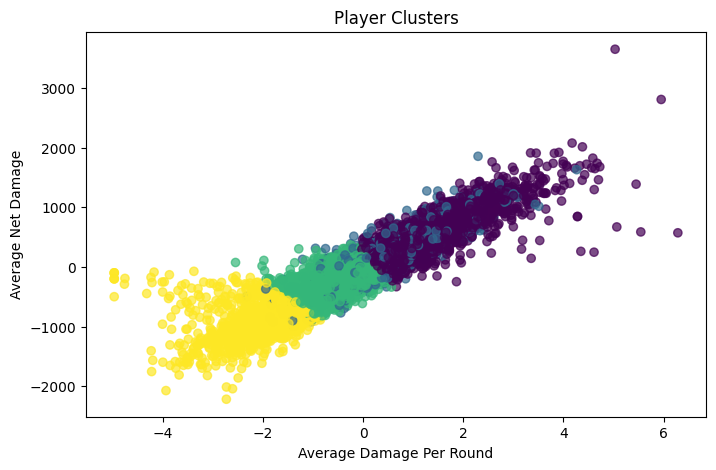

In [31]:
plt.figure(figsize=(8, 5))
plt.scatter(
    player_summary['damage_per_round'],
    player_summary['net_damage'],
    c=player_summary['cluster'],
    alpha=0.7
)
plt.xlabel('Average Damage Per Round')
plt.ylabel('Average Net Damage')
plt.title('Player Clusters')
plt.show()

In [32]:
centers = kmeans.cluster_centers_
print(centers)

[[ 0.93002801  0.64604389 -0.24194188]
 [ 0.28965841  0.31047219  1.55629055]
 [-0.42357288 -0.18903096 -0.39219882]
 [-1.87120293 -2.02591385 -0.63380537]]


<Figure size 800x500 with 0 Axes>

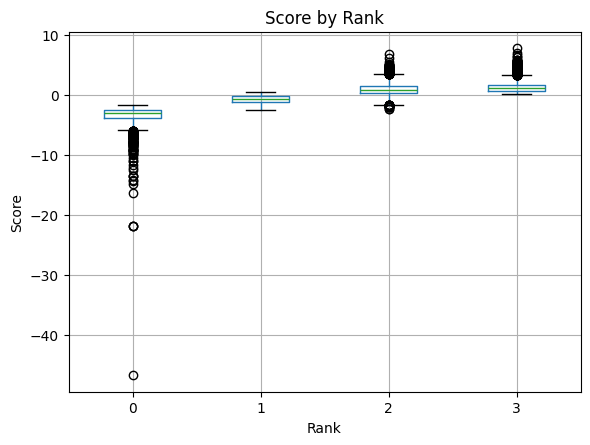

In [33]:
plt.figure(figsize=(8, 5))
player_summary.boxplot(column='score', by='rank')
plt.xlabel('Rank')
plt.ylabel('Score')
plt.title('Score by Rank')
plt.suptitle('')
plt.show()

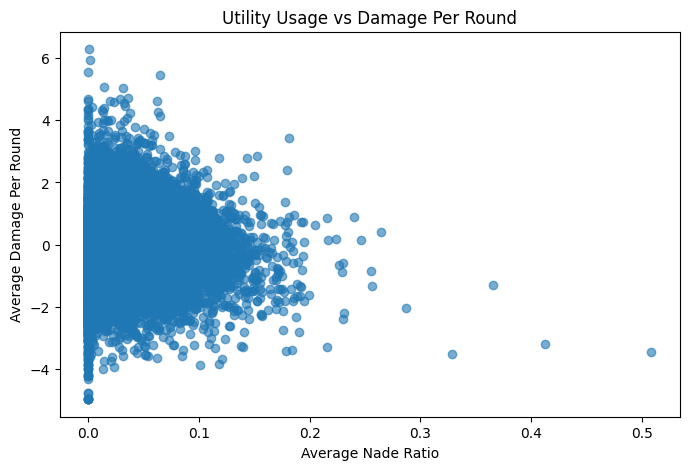

In [34]:
plt.figure(figsize=(8, 5))
plt.scatter(player_summary['nade_ratio'], player_summary['damage_per_round'], alpha=0.6)
plt.xlabel('Average Nade Ratio')
plt.ylabel('Average Damage Per Round')
plt.title('Utility Usage vs Damage Per Round')
plt.show()

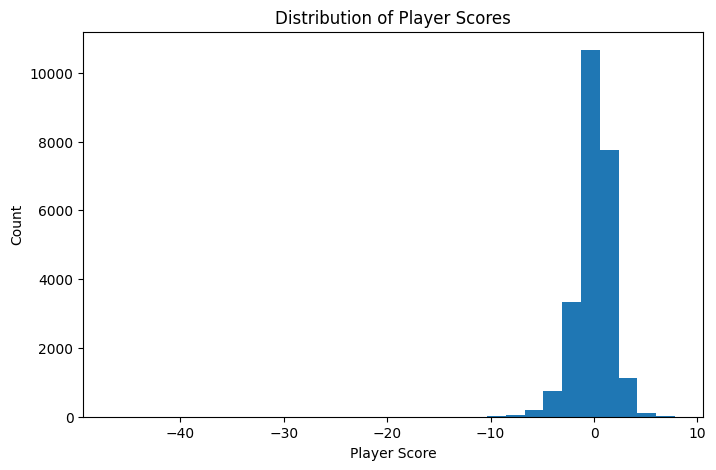

In [35]:
plt.figure(figsize=(8, 5))
plt.hist(player_summary['score'], bins=30)
plt.xlabel('Player Score')
plt.ylabel('Count')
plt.title('Distribution of Player Scores')
plt.show()

In [39]:
# Combine James and Bilal Datasets

clutch = pd.read_csv('../aggregated_stats.csv')

final = pd.merge(player_summary, clutch, left_on='player', right_on='id')

final = final[['player', 'damage_per_round', 'net_damage', 'total_damage', 'nade_damage', 'nade_ratio', 'net_dpr', 'totalhits', 'headshots' ,'headshotperhit', 'clutches', 'rounds_played', 'headshots_per_round', 'hits_per_round']]

In [43]:
final.to_csv('../complete_aggregation.csv', index = False)